[*********************100%***********************]  2 of 2 completed


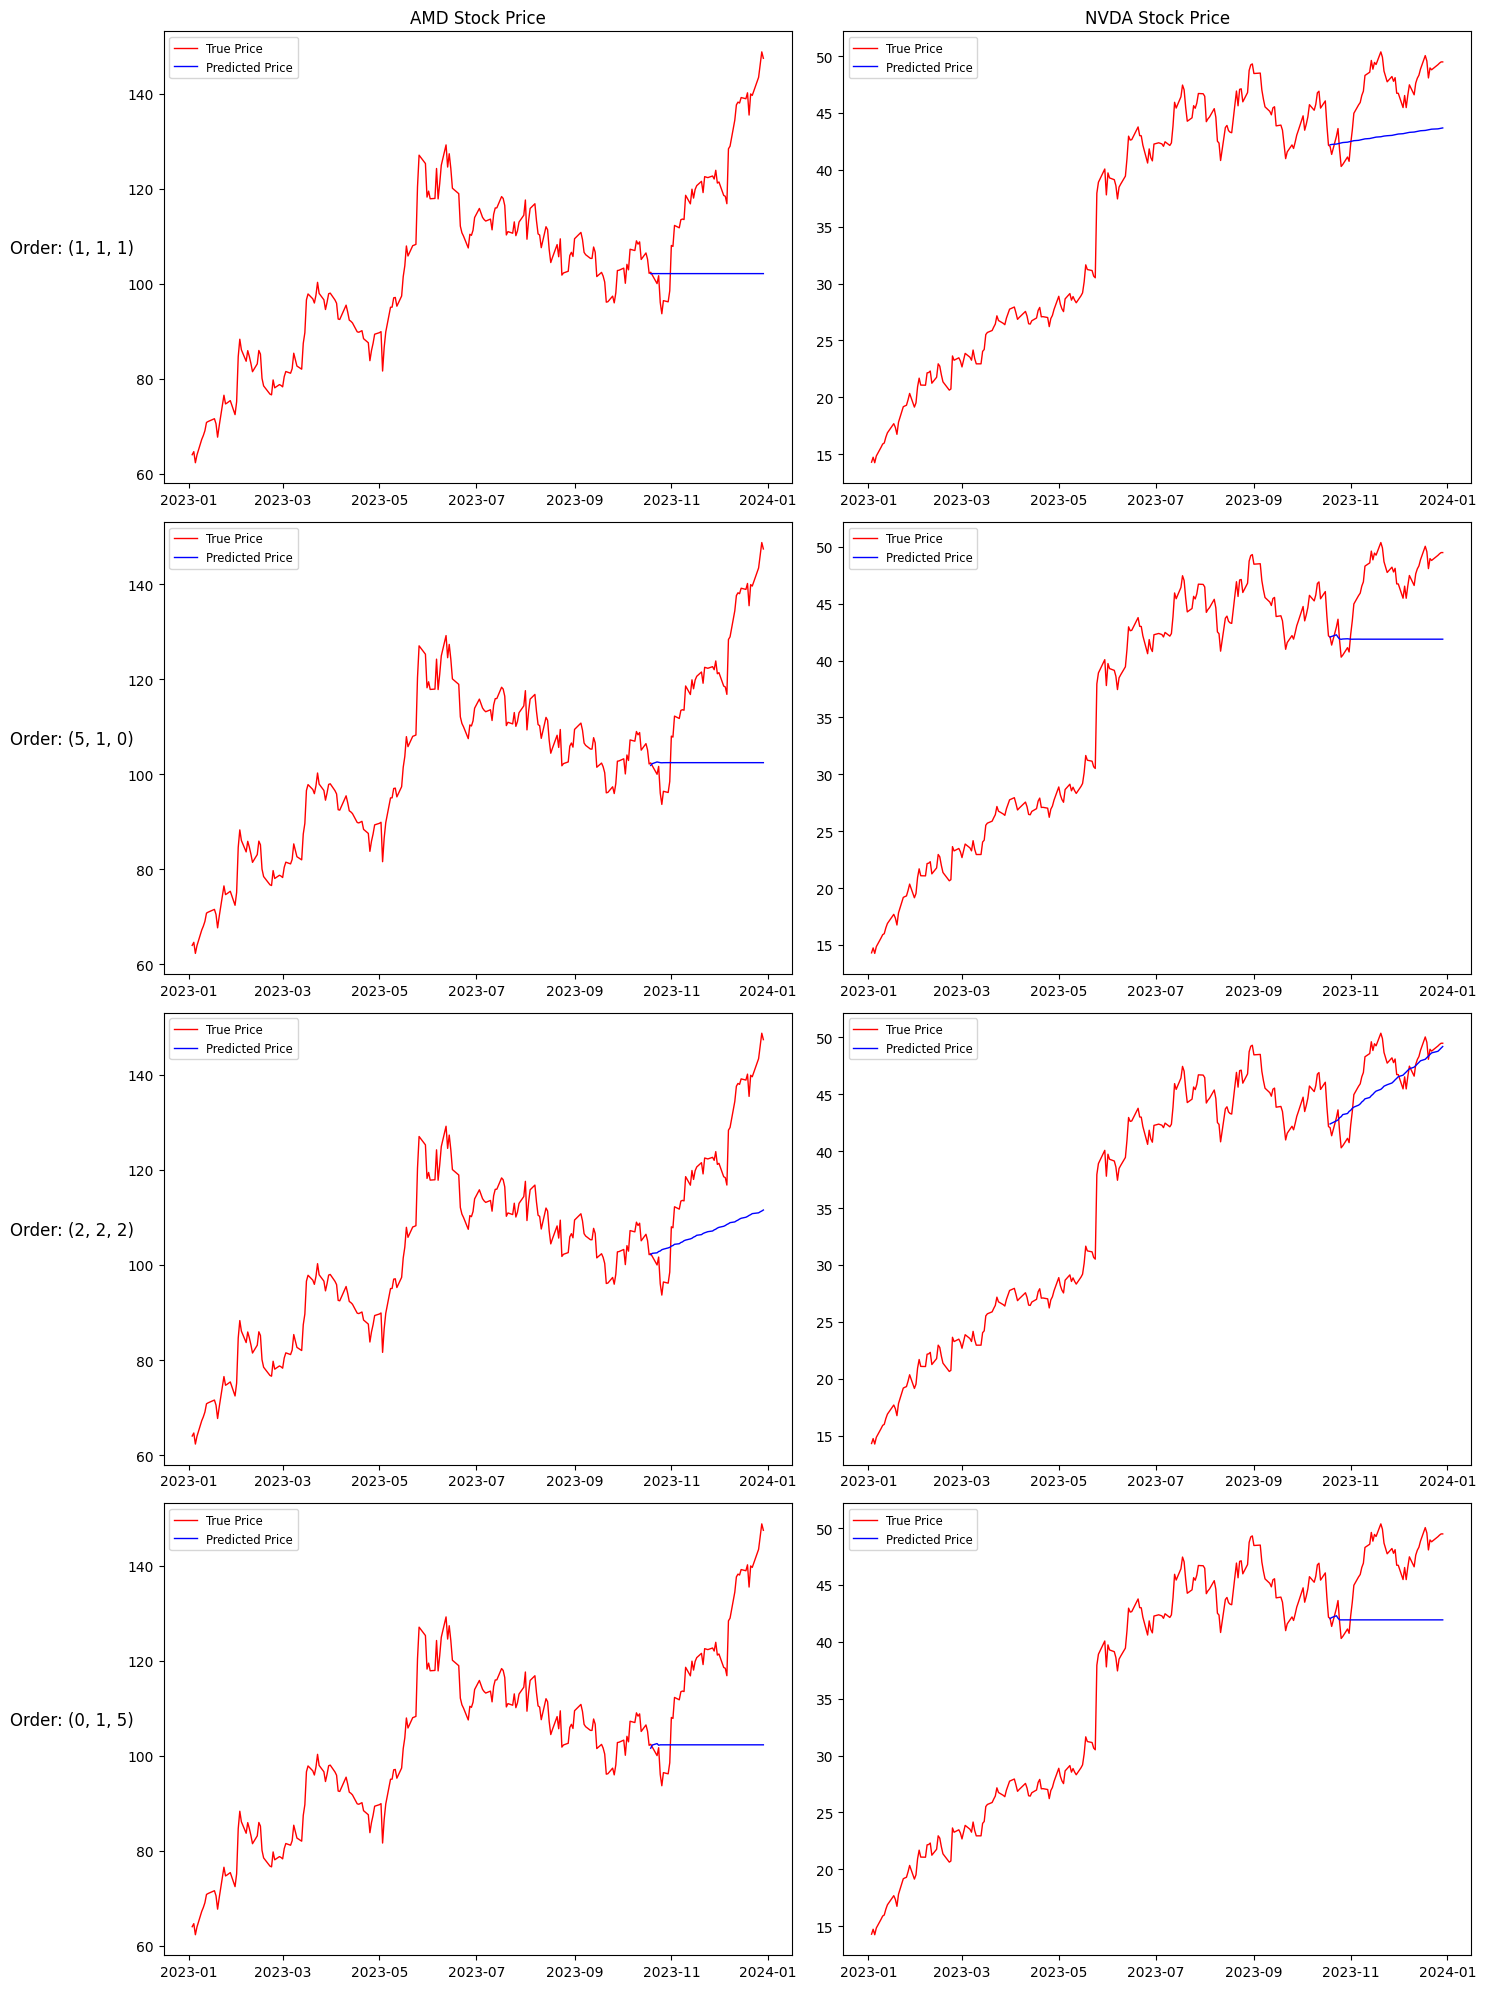

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import warnings

warnings.filterwarnings("ignore")

# 1. Download Real Data for AMD and NVIDIA
tickers = ['AMD', 'NVDA']
data = yf.download(tickers, start="2023-01-01", end="2024-01-01")['Close']

# 2. Define the ARIMA orders to compare
# In your source, different epochs were compared; here we compare different (p,d,q) orders [1]
orders = [(1, 1, 1), (5, 1, 0), (2, 2, 2), (0, 1, 5)]

fig, axes = plt.subplots(len(orders), 2, figsize=(15, 20))
plt.subplots_adjust(hspace=0.4)

for i, order in enumerate(orders):
    for j, ticker in enumerate(tickers):
        series = data[ticker].dropna()
        
        # Split data (simulating a simple train/test for visualization)
        train_size = int(len(series) * 0.8)
        train, test = series[0:train_size], series[train_size:]
        
        # Fit ARIMA Model
        model = ARIMA(train, order=order)
        model_fit = model.fit()
        
        # Forecast
        forecast = model_fit.get_forecast(steps=len(test))
        predicted_prices = forecast.predicted_mean
        
        # 3. Plotting similar to the provided source [1]
        # Red for True Price, Blue for Predicted Price as seen in source images [1]
        axes[i, j].plot(series.index, series, color='red', label='True Price', linewidth=1)
        axes[i, j].plot(test.index, predicted_prices, color='blue', label='Predicted Price', linewidth=1)
        
        if i == 0:
            axes[i, j].set_title(f"{ticker} Stock Price")
        if j == 0:
            axes[i, j].set_ylabel(f"Order: {order}", rotation=0, labelpad=40, fontsize=12)
            
        axes[i, j].legend(loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

[*********************100%***********************]  2 of 2 completed


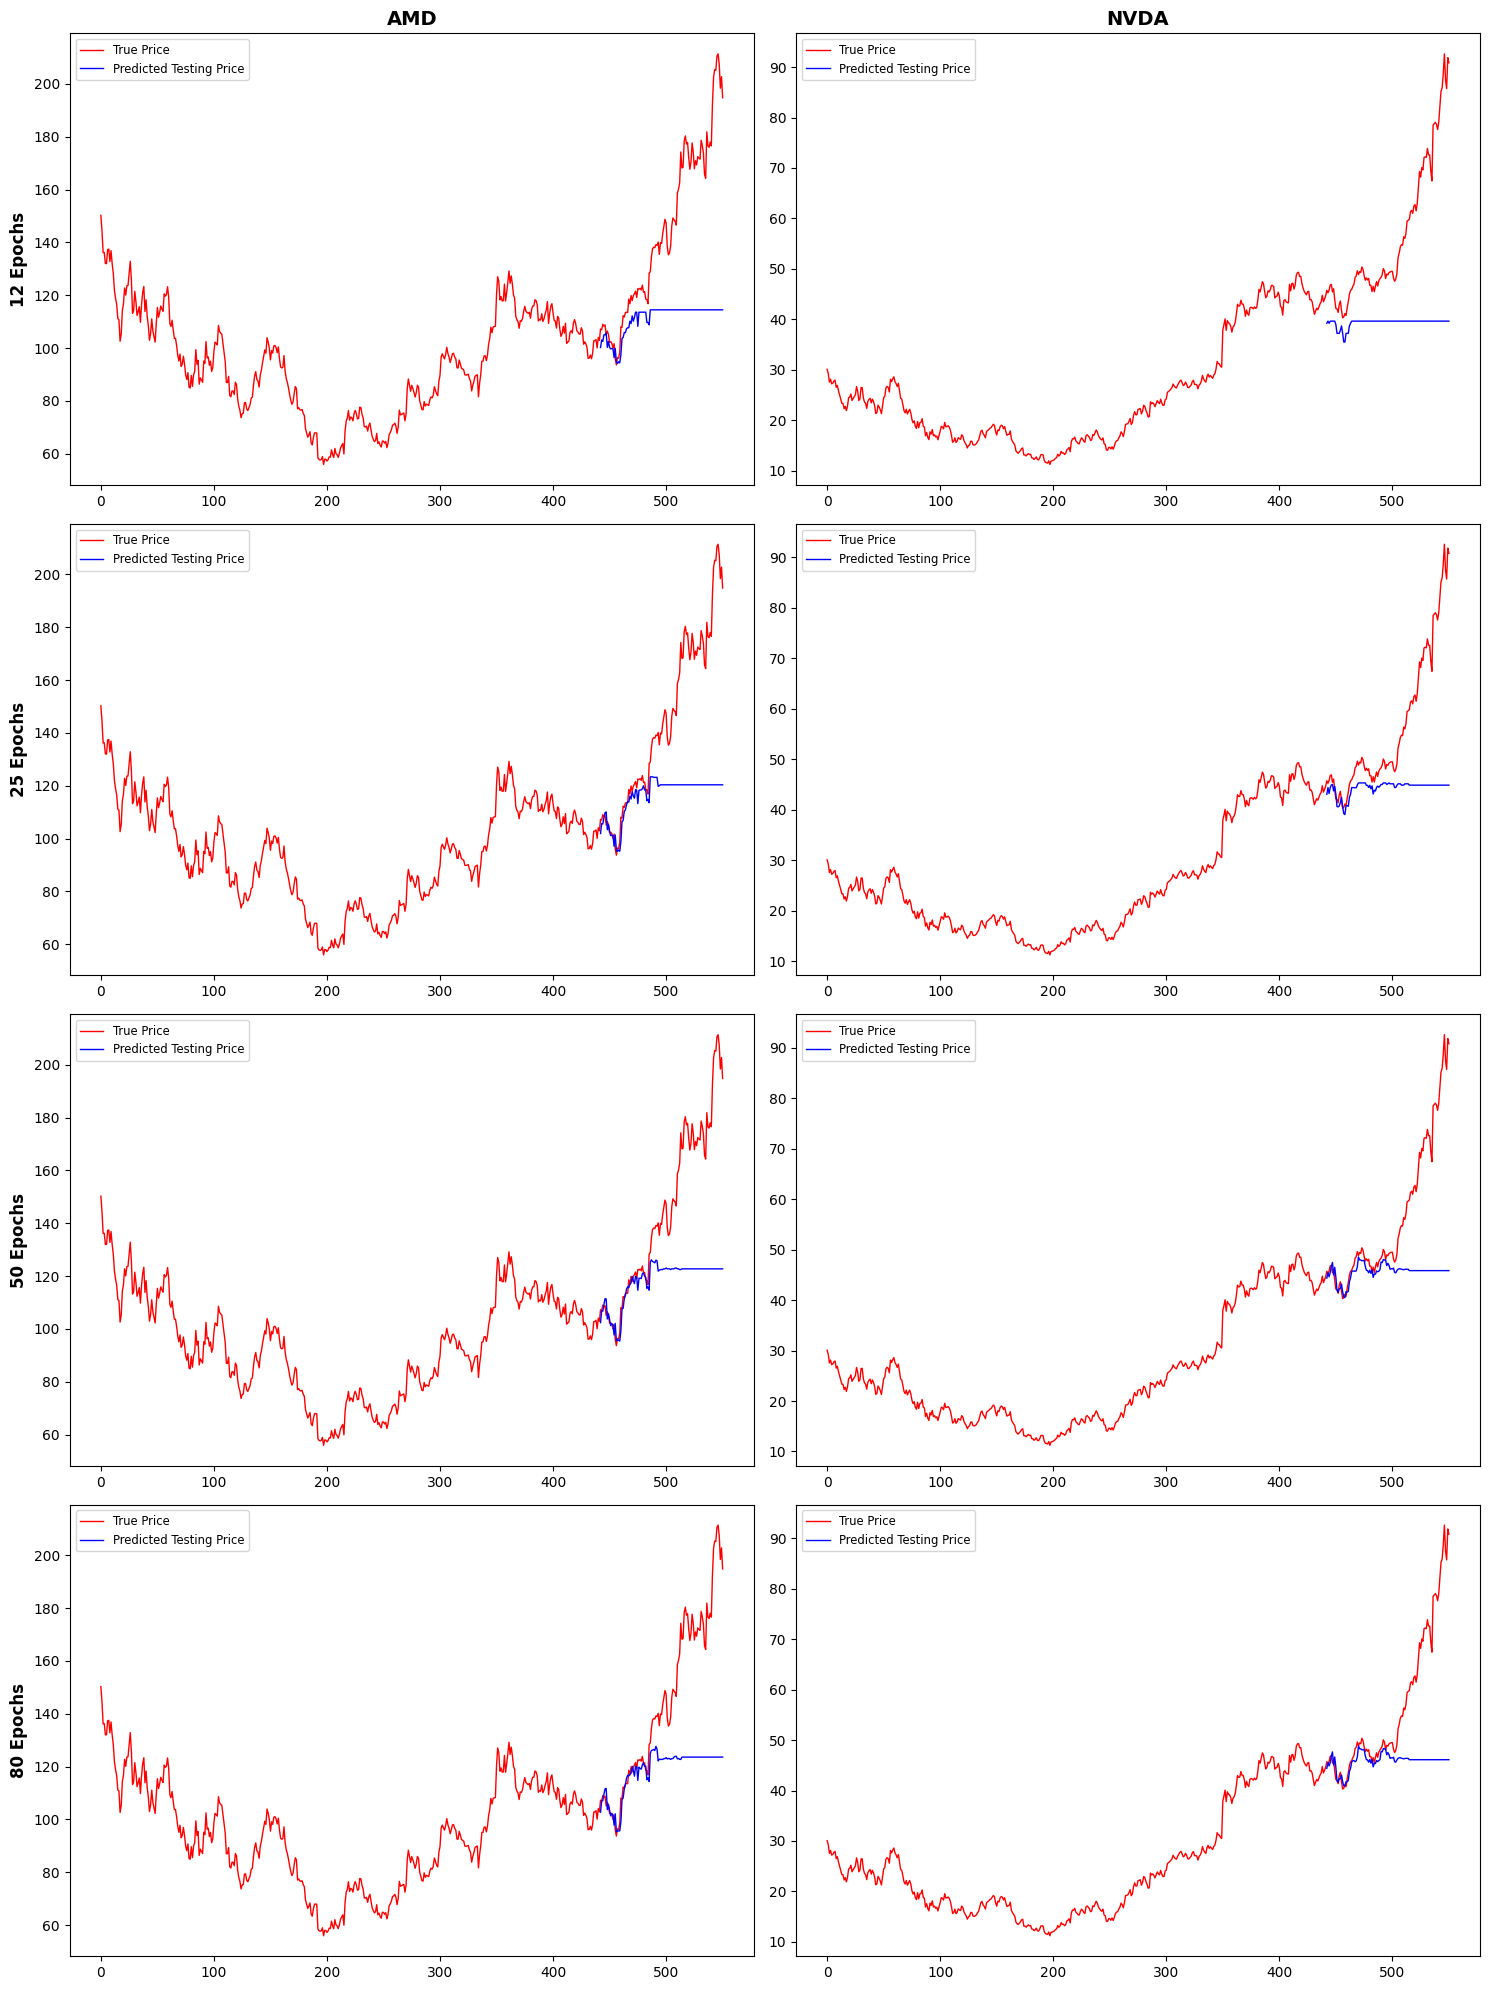

In [9]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# 1. Download Real Data
tickers = ['AMD', 'NVDA']
data = yf.download(tickers, start="2022-01-01", end="2024-03-14")['Close']

# 2. Parameters from Source [1]
# We map 'Epochs' to 'n_estimators' (boosting rounds) for XGBoost
epoch_list =  [12,25,50,80]
look_back = 10 # Days of history used to predict the next price

def create_features(series, look_back):
    X, y = [], []
    for i in range(len(series) - look_back):
        X.append(series[i:i + look_back])
        y.append(series[i + look_back])
    return np.array(X), np.array(y)

# 3. Plotting Setup (2 columns, 4 rows as per source [1])
fig, axes = plt.subplots(len(epoch_list), 2, figsize=(15, 20))

for row, n_est in enumerate(epoch_list):
    for col, ticker in enumerate(tickers):
        # Prepare Data
        series = data[ticker].dropna().values
        X, y = create_features(series, look_back)
        
        # Split: 80% Train, 20% Test
        train_size = int(len(X) * 0.8)
        X_train, X_test = X[:train_size], X[train_size:]
        y_train, y_test = y[:train_size], y[train_size:]
        
        # 4. Build and Train XGBoost Model
        # n_estimators corresponds to the "Epochs" in the source [1]
        model = XGBRegressor(n_estimators=n_est, learning_rate=0.1, max_depth=5)
        model.fit(X_train, y_train)
        
        # 5. Predict
        predictions = model.predict(X_test)
        
        # 6. Plotting (Following Source [1] Visuals)
        # Red = True Price, Blue = Predicted Testing Price
        axes[row, col].plot(series, color='red', label='True Price', linewidth=1)
        
        # Align prediction line to the end of the chart
        test_idx = np.arange(train_size + look_back, len(series))
        axes[row, col].plot(test_idx, predictions, color='blue', label='Predicted Testing Price', linewidth=1)
        
        # Formatting per Source [1]
        if row == 0:
            axes[row, col].set_title(ticker, fontsize=14, fontweight='bold')
        if col == 0:
            axes[row, col].set_ylabel(f"{n_est} Epochs", fontsize=12, fontweight='bold')
        
        axes[row, col].legend(loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()

In [8]:
!pip install xgboost

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 4.1 MB/s eta 0:00:25
    --------------------------------------- 2.4/101.7 MB 4.9 MB/s eta 0:00:21
   - -------------------------------------- 3.4/101.7 MB 5.2 MB/s eta 0:00:19
   - -------------------------------------- 4.7/101.7 MB 5.5 MB/s eta 0:00:18
   -- ------------------------------------- 6.0/101.7 MB 5.6 MB/s eta 0:00:18
   --- ------------------------------------ 7.9/101.7 MB 6.1 MB/s eta 0:00:16
   --- ------------------------------------ 8.1/101.7 MB 6.1 MB/s eta 0:00:16
   --- ------------------------------------ 8.7/101.7 MB 5.0 MB/s eta 0:00:19
   --- ------------------------------------ 9.7/101.7 MB 5.0 MB/s eta 0:00:19
   ---- ----------------------------------- 11.0/101.7 MB 5.4 MB/s eta 0:00:17
   ---- ----------------------------------- 11.3/101.7 MB 4.8 MB/s eta 0:00:1

In [5]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# 1. Download Real Data
tickers = ['AMD', 'NVDA']
data = yf.download(tickers, start="2020-01-01", end="2024-01-01")['Close']

# Parameters from the source image [1]
epoch_list = [12,25,50,80]
look_back = 60 # Using 60 days of history to predict the next day

def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back - 1):
        X.append(dataset[i:(i + look_back), 0])
        Y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(Y)

fig, axes = plt.subplots(len(epoch_list), 2, figsize=(15, 20))

for row, epochs in enumerate(epoch_list):
    for col, ticker in enumerate(tickers):
        # Prepare Data
        series = data[ticker].values.reshape(-1, 1)
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaled_data = scaler.fit_transform(series)
        
        train_size = int(len(scaled_data) * 0.8)
        train_data = scaled_data[:train_size]
        test_data = scaled_data[train_size - look_back:]
        
        X_train, y_train = create_dataset(train_data, look_back)
        X_test, y_test = create_dataset(test_data, look_back)
        
        X_train = np.reshape(X_train, (X_train.shape, X_train.shape[1], 1))
        X_test = np.reshape(X_test, (X_test.shape, X_test.shape[1], 1))

        # 2. Build the LSTM Model
        model = Sequential([
            LSTM(50, return_sequences=True, input_shape=(look_back, 1)),
            LSTM(50, return_sequences=False),
            Dense(25),
            Dense(1)
        ])
        
        model.compile(optimizer='adam', loss='mean_squared_error')
        model.fit(X_train, y_train, batch_size=32, epochs=epochs, verbose=0)
        
        # 3. Predictions
        predictions = model.predict(X_test)
        predictions = scaler.inverse_transform(predictions)
        true_prices = series[train_size:]

        # 4. Plotting (Following Source Style [1])
        # Red = True Price, Blue = Predicted Testing Price
        axes[row, col].plot(series, color='red', label='True Price', linewidth=1)
        # Shift predictions for plotting on the same x-axis
        test_idx = np.arange(train_size, train_size + len(predictions))
        axes[row, col].plot(test_idx, predictions, color='blue', label='Predicted Testing Price', linewidth=1)
        
        if row == 0:
            axes[row, col].set_title(ticker)
        if col == 0:
            axes[row, col].set_ylabel(f"{epochs} Epochs", fontsize=12, fontweight='bold')
        
        axes[row, col].legend(loc='upper left', fontsize='x-small')

plt.tight_layout()
plt.show()


[TensorFlow DLL Diagnostic] Analyzing: C:\Users\LENOVO\miniconda3\Lib\site-packages\tensorflow\python\_pywrap_tensorflow_internal.pyd
[Error] Failed to load _pywrap_tensorflow_common.dll: UNKNOWN ERROR (4551): [WinError 4551] An Application Control policy has blocked this file


ImportError: Traceback (most recent call last):
  File "C:\Users\LENOVO\miniconda3\Lib\site-packages\tensorflow\python\pywrap_tensorflow.py", line 74, in <module>
    from tensorflow.python._pywrap_tensorflow_internal import *
ImportError: DLL load failed while importing _pywrap_tensorflow_internal: An Application Control policy has blocked this file.


Failed to load the native TensorFlow runtime.
See https://www.tensorflow.org/install/errors for some common causes and solutions.
If you need help, create an issue at https://github.com/tensorflow/tensorflow/issues and include the entire stack trace above this error message.

[*********************100%***********************]  2 of 2 completed


ValueError: GRU: Expected input to be 2D or 3D, got 4D instead

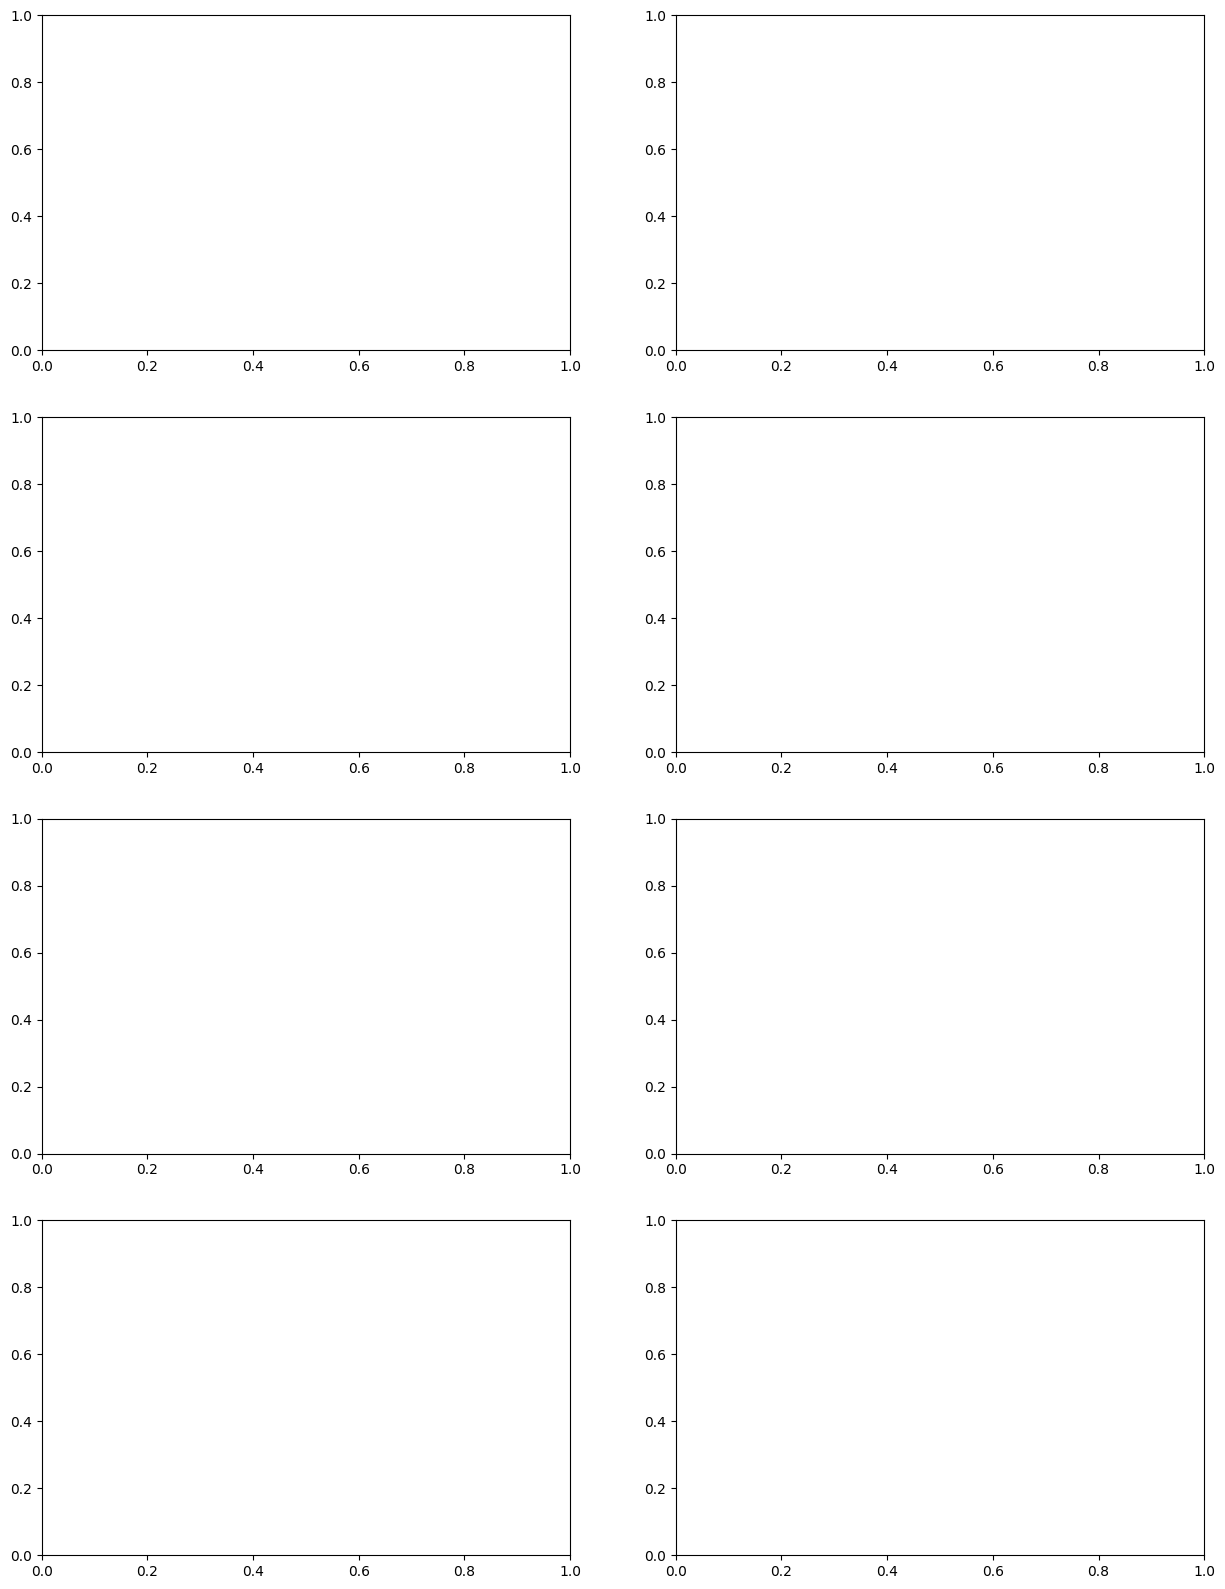

In [10]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler

# 1. Download Real Data
tickers = ['AMD', 'NVDA']
data = yf.download(tickers, start="2022-01-01", end="2024-03-14")['Close']

# Parameters from the source image [1]
epoch_list = [12,25,50,100]
look_back = 60 

# Define the GRU Model in PyTorch
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(GRUModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :]) 
        return out

def prepare_data(series, look_back):
    X, y = [], []
    for i in range(len(series) - look_back):
        X.append(series[i:i + look_back])
        y.append(series[i + look_back])
    return np.array(X), np.array(y)

# 2. Plotting Setup (Following Figure 4 Structure)
fig, axes = plt.subplots(len(epoch_list), 2, figsize=(15, 20))

for row, epochs in enumerate(epoch_list):
    for col, ticker in enumerate(tickers):
        # Data Preprocessing
        series = data[ticker].dropna().values.reshape(-1, 1)
        scaler = MinMaxScaler(feature_range=(0, 1))
        scaled_series = scaler.fit_transform(series)
        
        X, y = prepare_data(scaled_series, look_back)
        train_size = int(len(X) * 0.8)
        
        # Convert to PyTorch Tensors
        X_train = torch.from_numpy(X[:train_size]).type(torch.Tensor).unsqueeze(-1)
        y_train = torch.from_numpy(y[:train_size]).type(torch.Tensor).unsqueeze(-1)
        X_test = torch.from_numpy(X[train_size:]).type(torch.Tensor).unsqueeze(-1)

        # 3. Model Training
        model = GRUModel(input_dim=1, hidden_dim=32, num_layers=2, output_dim=1)
        criterion = nn.MSELoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

        for epoch in range(epochs):
            model.train()
            outputs = model(X_train)
            loss = criterion(outputs, y_train)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        # 4. Predictions
        model.eval()
        with torch.no_grad():
            predictions = model(X_test).numpy()
            predictions = scaler.inverse_transform(predictions)

        # 5. Visualizing (Matching Figure 4 Style) [1]
        # Red = True Price, Blue = Predicted Testing Price
        axes[row, col].plot(series, color='red', label='True Price', linewidth=1)
        
        test_idx = np.arange(train_size + look_back, len(series))
        axes[row, col].plot(test_idx, predictions, color='blue', label='Predicted Testing Price', linewidth=1)
        
        if row == 0:
            axes[row, col].set_title(ticker, fontsize=14, fontweight='bold')
        if col == 0:
            axes[row, col].set_ylabel(f"{epochs} Epochs", fontsize=12, fontweight='bold')
        
        axes[row, col].legend(loc='upper left', fontsize='small')

plt.tight_layout()
plt.show()